# **DBSCAN vs OPTICS Clustering:**
DBSCAN and OPTICS are both density-based clustering algorithms that group together data points that are close to each other in the feature space. However, there are some differences between the two algorithms in terms of performance and scalability:


Here’s a clear comparison between **DBSCAN** and **OPTICS**, two popular density-based clustering algorithms, presented in a tabular format for easy understanding:

---

### **DBSCAN vs. OPTICS: Key Differences**

| Feature                | **DBSCAN**                          | **OPTICS**                          |
|------------------------|-------------------------------------|-------------------------------------|
| **Full Form**          | Density-Based Spatial Clustering of Applications with Noise | Ordering Points To Identify the Clustering Structure |
| **Key Idea**           | Groups points based on density (`eps` and `minPts`) | Creates an "ordering" of points to reveal clusters at varying densities |
| **Parameters**         | - `eps` (fixed radius) <br> - `minPts` (min neighbors) | - `minPts` (core point threshold) <br> - `max_eps` (optional upper bound) |
| **Density Handling**   | Uses a **single fixed density** (`eps`) | Handles **varying densities** (no fixed `eps`) |
| **Output**            | Direct cluster labels (`-1` = noise) | 1. **Reachability plot** (visual tool) <br> 2. Cluster labels (extracted later) |
| **Speed**             | Faster (computes neighbors once) | Slower (builds reachability ordering) |
| **Use Cases**         | - Uniform density datasets <br> - Outlier detection | - Multi-density datasets (e.g., cities + rural areas) <br> - Hierarchical clustering |
| **Strengths**         | Simple, fast, works well with clear density thresholds | Flexible, discovers clusters of varying shapes/sizes |
| **Weaknesses**        | Struggles with varying densities | More complex to interpret (requires reachability plot) |

---

### **Key Differences Explained**

#### 1. **Density Flexibility**
- **DBSCAN**: Requires a fixed `eps`.  
  - Example: Fails if some clusters are dense (city) and others sparse (countryside).  
- **OPTICS**: Adapts to local densities automatically.  
  - Example: Can detect both tight city clusters and wide rural clusters in the same dataset.

#### 2. **Output**
- **DBSCAN**: Directly assigns labels (e.g., `[0, 0, -1, 1, 1]`).  
- **OPTICS**: Generates a **reachability plot** (like a bar chart showing density valleys), which you then analyze to extract clusters.

#### 3. **Parameter Sensitivity**
- **DBSCAN**: Highly sensitive to `eps`. A bad choice merges clusters or ignores noise.  
- **OPTICS**: Only needs `minPts` (though `max_eps` can speed it up).

#### 4. **Visualization**
- **DBSCAN**: Clusters are static.  
- **OPTICS**: Reachability plots reveal hierarchical structures (nested clusters).

---

### **When to Use Which?**
- **Choose DBSCAN** if:  
  - Your data has uniform density.  
  - You need fast results.  
  - You already know a good `eps` (e.g., from a `KneeLocator`).  

- **Choose OPTICS** if:  
  - Your data has varying densities (e.g., satellite images, geographic data).  
  - You want to explore hierarchical relationships.  
  - You’re unsure about `eps` and want to avoid guesswork.  

---

### **Example Code Comparison**

#### **DBSCAN Implementation**
```python
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels = dbscan.fit_predict(X)
```

#### **OPTICS Implementation**
```python
from sklearn.cluster import OPTICS
optics = OPTICS(min_samples=5, max_eps=np.inf)
labels = optics.fit_predict(X)

# Plot reachability plot (OPTICS-specific)
import matplotlib.pyplot as plt
plt.plot(optics.reachability_[optics.ordering_])
plt.show()
```

---

### **Real-World Analogy**
- **DBSCAN**: Like using a fixed-size net to catch fish—works if all fish swim in similar densities.  
- **OPTICS**: Like a smart net that adjusts its holes based on fish density—catches both tight schools and scattered fish.  



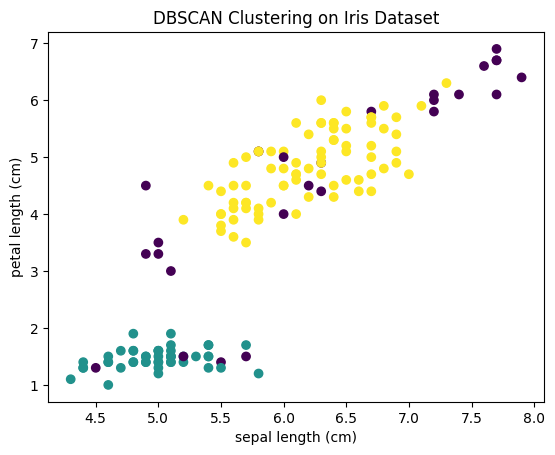

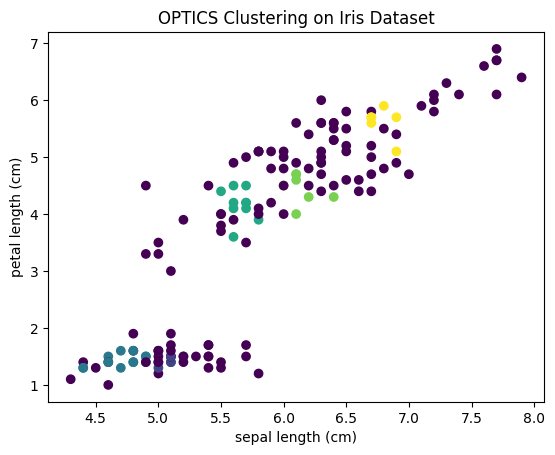

In [1]:
from sklearn.datasets import load_iris
from sklearn.cluster import DBSCAN, OPTICS
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Load the iris dataset
iris = load_iris()
X = iris.data

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create the DBSCAN object
dbscan = DBSCAN(eps=0.6, min_samples=5)

# Create the OPTICS object
optics = OPTICS(min_samples=5, xi=0.05)

# Fit the models
dbscan.fit(X_scaled)
optics.fit(X_scaled)

# Plot the data points with color-coded clusters for DBSCAN
plt.scatter(X[:, 0], X[:, 2], c=dbscan.labels_)
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[2])
plt.title("DBSCAN Clustering on Iris Dataset")
plt.show()

# Plot the data points with color-coded clusters for OPTICS
plt.scatter(X[:, 0], X[:, 2], c=optics.labels_)
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[2])
plt.title("OPTICS Clustering on Iris Dataset")
plt.show()